In [661]:
#imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [662]:
df = pd.read_excel("Data_sets/Concilio Raw Data.xlsx")
print("num or rows", df.shape[0])
df.sample(10)

num or rows 4778


,Unnamed: 0,Gender,Age,# of Adults in Household,# of Children 0-5,# of Children 6-12,# of Children 13-17,Race/Ethnicity,Mailing County,Mailing Zip/Postal Code,Total Household Income,Veteran,Medical Benefits,SNAP Participant
4427,NaN,Female,37,1.0,0.0,NaN,NaN,Hispanic,Denton,75007.0,"$44,501 - $71,200",0.0,Uninsured,No
3165,NaN,Male,54,2.0,0.0,0.0,0.0,Hispanic,Dallas,75238.0,"$26,701 - $44,500",0.0,CHIP; Uninsured,No
1612,NaN,Female,40,1.0,0.0,1.0,0.0,Hispanic,Dallas,75214.0,Does not want to disclose,0.0,Prefer Not to Answer,Prefer Not to Answer
3714,NaN,Female,51,4.0,0.0,0.0,0.0,Hispanic,Dallas,75203.0,Does not want to disclose,0.0,Prefer Not to Answer,No
210,NaN,Female,35,1.0,0.0,1.0,0.0,Hispanic,Dallas,75254.0,"Under $26,700",0.0,CHIP,Yes
3079,NaN,Female,35,2.0,2.0,0.0,0.0,Hispanic,Dallas,75254.0,"$26,701 - $44,500",0.0,Medicaid,No
3182,NaN,Female,Unknown,5.0,0.0,1.0,1.0,Hispanic,Dallas,75181.0,"Under $26,700",0.0,Prefer Not to Answer,No
1739,NaN,Female,50,4.0,0.0,1.0,0.0,Hispanic,Dallas,75211.0,"$26,701 - $44,500",0.0,Other,No
4192,NaN,Female,34,1.0,1.0,0.0,2.0,Prefer Not to Answer,Dallas,75080.0,"$44,501 - $71,200",0.0,Uninsured,No
3728,NaN,Female,49,3.0,0.0,0.0,0.0,Hispanic,Dallas,75007.0,"$26,701 - $44,500",0.0,Uninsured,No


In [663]:
# Dropping the first unnamed column
df = df.drop("Unnamed: 0", axis=1)
df.head()

,Gender,Age,# of Adults in Household,# of Children 0-5,# of Children 6-12,# of Children 13-17,Race/Ethnicity,Mailing County,Mailing Zip/Postal Code,Total Household Income,Veteran,Medical Benefits,SNAP Participant
0,Male,30,2.0,0.0,1.0,0.0,Hispanic,Dallas,75006.0,Unknown,0.0,Uninsured,No
1,Female,26,2.0,3.0,0.0,0.0,Hispanic,Dallas,75006.0,"Under $26,700",0.0,Medicaid,Yes
2,Female,37,2.0,0.0,1.0,0.0,Hispanic,Dallas,75006.0,Does not want to disclose,0.0,Uninsured,No
3,Female,38,2.0,0.0,2.0,0.0,Hispanic,Dallas,75006.0,Unknown,0.0,Uninsured,No
4,Female,41,4.0,0.0,1.0,1.0,Hispanic,Dallas,75006.0,"Under $26,700",0.0,Uninsured,No


In [664]:
# Convert 'Age' column to numeric to make errors become Nan and dropping
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
mean_age = df['Age'].mean()
print("Mean age", mean_age)
print("Is Nan", df['Age'].isna().sum())
df = df.dropna(subset=['Age'])
print("Is Nan", df['Age'].isna().sum())

Mean age 40.21457673155274
Is Nan 360
Is Nan 0


In [665]:
# Checking Unknowns in Gender
print(df[(df['Gender'] != "Male") & (df['Gender'] != "Female") & (df['Gender'] != "Prefer Not to Answer")].shape[0])
df = df[df['Gender'].isin(["Male", "Female", "Prefer Not to Answer"])]
df[(df['Gender'] != "Male") & (df['Gender'] != "Female") & (df['Gender'] != "Prefer Not to Answer")].shape[0]

43


0

In [666]:
# Removing counties not in specified list
print(df[~df['Mailing County'].isin(["Dallas", "Tarrant", "Denton", "Collin", "Rockwall", "Kaufman", "Ellis", "Johnson", "Parker", "Wise"])].shape[0])
df = df[df['Mailing County'].isin(["Dallas", "Tarrant", "Denton", "Collin", "Rockwall", "Kaufman", "Ellis", "Johnson", "Parker", "Wise"])]
print(df[~df['Mailing County'].isin(["Dallas", "Tarrant", "Denton", "Collin", "Rockwall", "Kaufman", "Ellis", "Johnson", "Parker", "Wise"])].shape[0])

46
0


In [667]:
# checking for unexpected values in # of Adults in household
df['# of Adults in Household'] = pd.to_numeric(df['# of Adults in Household'], errors='coerce')
print (df['# of Adults in Household'].isna().sum())
df.sample(10)

0


,Gender,Age,# of Adults in Household,# of Children 0-5,# of Children 6-12,# of Children 13-17,Race/Ethnicity,Mailing County,Mailing Zip/Postal Code,Total Household Income,Veteran,Medical Benefits,SNAP Participant
4329,Female,60.0,2.0,0.0,2.0,0.0,Hispanic,Dallas,75230.0,Unknown,0.0,Uninsured,No
35,Female,41.0,2.0,2.0,0.0,0.0,Hispanic,Dallas,75006.0,Unknown,0.0,Medicaid,Prefer Not to Answer
554,Female,35.0,5.0,1.0,0.0,0.0,Black or African American,Dallas,75216.0,"$26,701 - $44,500",0.0,Private,No
4636,Female,53.0,3.0,2.0,0.0,0.0,Hispanic,Dallas,75227.0,Unknown,0.0,Medicaid,Yes
879,Female,43.0,2.0,1.0,2.0,0.0,Hispanic,Dallas,75253.0,"Over $71,200",0.0,Uninsured,No
4606,Male,38.0,2.0,1.0,1.0,1.0,Hispanic,Dallas,75214.0,Unknown,0.0,Medicaid,No
728,Female,54.0,4.0,0.0,1.0,0.0,Hispanic,Dallas,75231.0,"Under $26,700",0.0,Uninsured,No
4294,Female,35.0,1.0,1.0,0.0,1.0,Hispanic,Dallas,75211.0,Unknown,0.0,Medicaid,Yes
4231,Female,34.0,2.0,1.0,0.0,1.0,Hispanic,Dallas,75080.0,Unknown,0.0,Medicaid,Yes
1360,Female,57.0,2.0,0.0,2.0,1.0,Hispanic,Dallas,75212.0,"Under $26,700",0.0,Prefer Not to Answer,No


In [668]:
# checking for unexpected values in # of Adults in household
df['# of Children 0-5'] = pd.to_numeric(df['# of Children 0-5'], errors='coerce')
print ('0 - 5',df['# of Children 0-5'].isna().sum())

df['# of Children 6-12'] = pd.to_numeric(df['# of Children 6-12'], errors='coerce')
print ('6 - 12',df['# of Children 6-12'].isna().sum())

df['# of Children 13-17'] = pd.to_numeric(df['# of Children 13-17'], errors='coerce')
print ('13 - 17',df['# of Children 13-17'].isna().sum())

# dropping all nan values
df = df.dropna(subset=['# of Children 0-5'])
df = df.dropna(subset=['# of Children 6-12'])
df = df.dropna(subset=['# of Children 13-17'])

0 - 5 4
6 - 12 32
13 - 17 32


### Household Income Comments
Original datasets had numerous categories for this column; had to streamline to four major categories (overlap created as result)  

Ranges are:  
    Under $26,700  
    $26,701 - $44,500  
    $44,501 - $71,200  
    Over $71,200   



Also, added ordinal mapping as well to make it easy to work with.
Mapping:  
    Nan = -1  
    Prefer Not to Answer = 0  
    Under $26,700 = 1  
    $26,701 - $44,500 = 2  
    $44,501 - $71,200 = 3  
    Over $71,200 = 4  

In [669]:
# cleaning household income range
# created mapped income range to present a more consistent range among data
# Ranges are:
# Under $26,700
# $26,701 - $44,500
# $44,501 - $71,200
# Over $71,200

def normalize_text(s):
    if pd.isna(s) or s == "":
        return s
    s = s.strip().lower()
    s = re.sub(r'\s*-\s*', ' - ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

df['normalized_income'] = df['Total Household Income'].apply(normalize_text)

mapping = {
    "under $26,700": "Under $26,700",
    "less than $25,100": "Under $26,700",
    "$26,701 - $44,500": "$26,701 - $44,500",
    "$25,101 - $38,600": "$26,701 - $44,500",
    "$44,501 - $71,200": "$44,501 - $71,200",
    "$38,601 - $61,750": "$44,501 - $71,200",
    "over $71,200": "Over $71,200",
    "more than $61,750": "Over $71,200",
    "does not want to disclose": "Prefer Not to Answer",
    "do not want to disclose" : "Prefer Not to Answer",
    "unknown": np.nan,
    "": np.nan
}
df['mapped_income_range'] = df['normalized_income'].map(mapping)
df = df.drop('normalized_income', axis=1)
print (df['mapped_income_range'].isna().sum())
df.sample(10)

867


,Gender,Age,# of Adults in Household,# of Children 0-5,# of Children 6-12,# of Children 13-17,Race/Ethnicity,Mailing County,Mailing Zip/Postal Code,Total Household Income,Veteran,Medical Benefits,SNAP Participant,mapped_income_range
3022,Female,32.0,2.0,2.0,0.0,0.0,Hispanic,Dallas,75231.0,Does not want to disclose,0.0,Medicaid,No,Prefer Not to Answer
1169,Female,45.0,1.0,0.0,1.0,1.0,Hispanic,Dallas,75217.0,Unknown,0.0,Prefer Not to Answer,No,NaN
344,Female,51.0,2.0,0.0,1.0,0.0,Hispanic,Dallas,75323.0,"Under $26,700",0.0,Prefer Not to Answer,Yes,"Under $26,700"
1424,Female,28.0,2.0,1.0,2.0,0.0,Hispanic,Dallas,75149.0,"$26,701 - $44,500",0.0,Uninsured,No,"$26,701 - $44,500"
2624,Female,41.0,2.0,2.0,0.0,0.0,Hispanic,Dallas,75227.0,"Over $71,200",0.0,Prefer Not to Answer,No,"Over $71,200"
3200,Female,37.0,2.0,1.0,1.0,1.0,Hispanic,Dallas,75149.0,"$26,701 - $44,500",0.0,Medicaid,No,"$26,701 - $44,500"
2763,Female,42.0,3.0,0.0,1.0,0.0,Hispanic,Dallas,75210.0,"$26,701 - $44,500",0.0,Prefer Not to Answer,No,"$26,701 - $44,500"
904,Female,59.0,2.0,0.0,0.0,1.0,Hispanic,Dallas,75217.0,"$26,701 - $44,500",0.0,Uninsured,No,"$26,701 - $44,500"
3004,Female,26.0,2.0,2.0,0.0,0.0,Asian,Dallas,75231.0,Unknown,0.0,Medicaid,No,NaN
3207,Female,39.0,1.0,0.0,1.0,0.0,Hispanic,Dallas,75149.0,"Under $26,700",0.0,Uninsured,No,"Under $26,700"


In [670]:
# Mapping income to numerical values
# Nan = -1
# Prefer Not to Answer = 0
# Under $26,700 = 1
# $26,701 - $44,500 = 2
# $$44,501 - $71,200 = 3
# Over $71,200 = 4

order_mapping = {
    np.nan : -1,
    "Prefer Not to Answer" : 0,
    "Under $26,700" : 1,
    "$26,701 - $44,500" : 2,
    "$44,501 - $71,200" : 3,
    "Over $71,200" : 4
}
df['income_range_ordinal'] = df['mapped_income_range'].map(order_mapping)

In [671]:
df.to_excel('cleaned_concilio_data.xlsx', index=False)

# Data Visualization

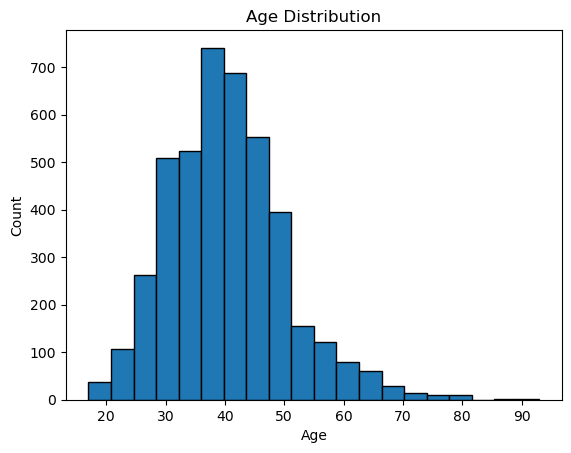

In [672]:
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

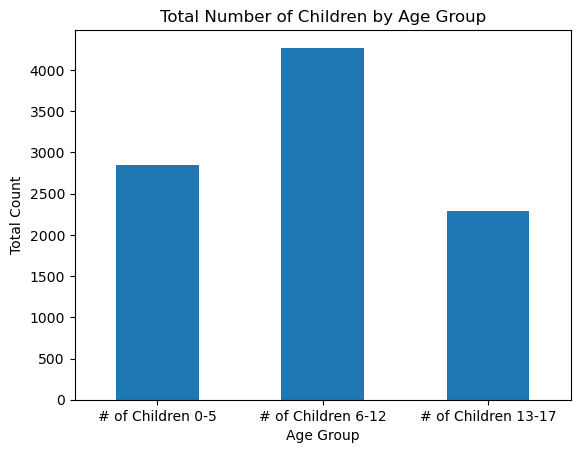

In [673]:
children_counts = df[['# of Children 0-5', '# of Children 6-12', '# of Children 13-17']].sum()

children_counts.plot(kind='bar')
plt.title('Total Number of Children by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Count')
plt.xticks(rotation=0) 
plt.show()

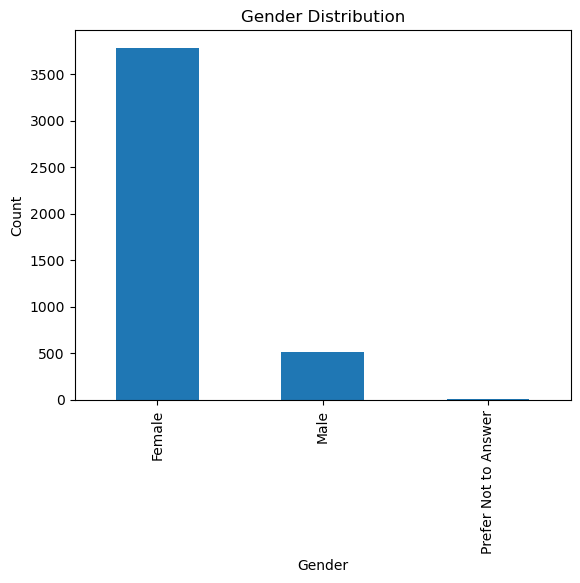

In [674]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

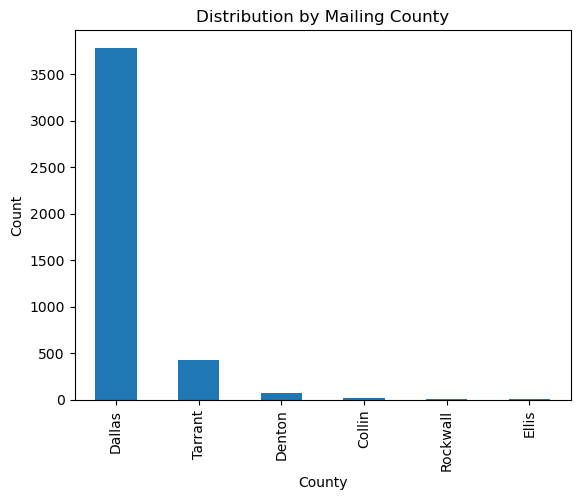

In [675]:
df['Mailing County'].value_counts().plot(kind='bar')
plt.title('Distribution by Mailing County')
plt.xlabel('County')
plt.ylabel('Count')
plt.show()

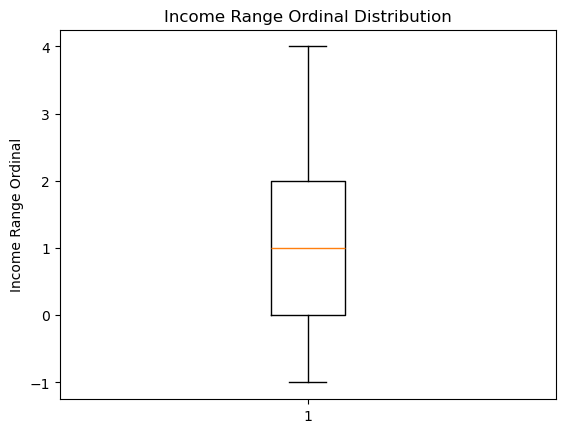

In [676]:
# Mapping income to numerical values
# Nan = -1
# Prefer Not to Answer = 0
# Under $26,700 = 1
# $26,701 - $44,500 = 2
# $$44,501 - $71,200 = 3
# Over $71,200 = 4

plt.boxplot(df['income_range_ordinal'])
plt.title('Income Range Ordinal Distribution')
plt.ylabel('Income Range Ordinal')
plt.show()

In [677]:
income_order = ['Under $26,700', '$26,701 - $44,500', '$44,501 - $71,200', 'Over $71,200', 'Prefer Not to Answer']

df['mapped_income_range'] = pd.Categorical(df['mapped_income_range'], categories=income_order, ordered=True)
df.head()


,Gender,Age,# of Adults in Household,# of Children 0-5,# of Children 6-12,# of Children 13-17,Race/Ethnicity,Mailing County,Mailing Zip/Postal Code,Total Household Income,Veteran,Medical Benefits,SNAP Participant,mapped_income_range,income_range_ordinal
0,Male,30.0,2.0,0.0,1.0,0.0,Hispanic,Dallas,75006.0,Unknown,0.0,Uninsured,No,NaN,-1
1,Female,26.0,2.0,3.0,0.0,0.0,Hispanic,Dallas,75006.0,"Under $26,700",0.0,Medicaid,Yes,"Under $26,700",1
2,Female,37.0,2.0,0.0,1.0,0.0,Hispanic,Dallas,75006.0,Does not want to disclose,0.0,Uninsured,No,Prefer Not to Answer,0
3,Female,38.0,2.0,0.0,2.0,0.0,Hispanic,Dallas,75006.0,Unknown,0.0,Uninsured,No,NaN,-1
4,Female,41.0,4.0,0.0,1.0,1.0,Hispanic,Dallas,75006.0,"Under $26,700",0.0,Uninsured,No,"Under $26,700",1


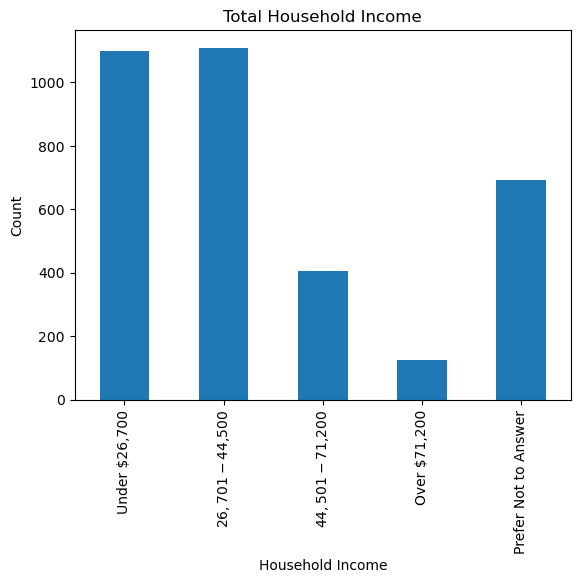

In [678]:
df['mapped_income_range'].value_counts(sort=False).plot(kind='bar')
plt.title('Total Household Income')
plt.xlabel('Household Income')
plt.ylabel('Count')
plt.show()